In this notebook we compare the networkx library with our library. 

It is important to note that conventions differs:
* network_simplex: ``outgoing - incoming = balance``; supply is positive.
* NetworkX: ``incoming - outgoing = demand``; demand is positive.

Therefore each node is passed to NetworkX with ``demand=-balance``.


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from network_simplex import Arc, Network, NetworkSimplex, Node

# Comparing a Unique Solution

## Defining the network

In [ ]:
# This instance has a unique optimum, so both the total cost and individual
# arc flows can be compared directly.

NODES = [
    Node("factory", balance=8),
    Node("crossdock", balance=0),
    Node("retail", balance=-5),
    Node("hospital", balance=-3),
]

ARCS = [
    Arc("factory_crossdock", "factory", "crossdock", cost=1),
    Arc("crossdock_retail", "crossdock", "retail", cost=2),
    Arc("crossdock_hospital", "crossdock", "hospital", cost=1),
    Arc("factory_retail", "factory", "retail", cost=6),
    Arc("factory_hospital", "factory", "hospital", cost=5),
]

# Build the graph before drawing it.
graph = nx.DiGraph()
for node in NODES:
    graph.add_node(node.id, demand=-node.balance)
for arc in ARCS:
    graph.add_edge(arc.tail, arc.head, weight=arc.cost, arc_id=arc.id)

# Dibujar
plt.figure(figsize=(4, 4))
pos = {
    'factory': (0, 0),
    'crossdock': (3, 1),
    'retail': (4, -1),
    'hospital': (5, 1)
}
# Dibujar nodos
nx.draw_networkx_nodes(graph, pos, node_size=1500, node_color='lightblue')

# Dibujar etiquetas de nodos con balances
labels = {}
for node in NODES:
    labels[node.id] = f"{node.id}\n(b={node.balance})"
nx.draw_networkx_labels(graph, pos, labels, font_size=10)

# Dibujar aristas
nx.draw_networkx_edges(graph, pos, edge_color='gray', arrows=True, arrowsize=50,arrowstyle='->')

# Dibujar etiquetas de aristas (costos)
edge_labels = nx.get_edge_attributes(graph, 'weight')
edge_labels = {k: f"c={v}" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(graph, pos, edge_labels, font_size=9)

plt.title("Red de Flujo - Nodos y Aristas")
plt.axis('off')
plt.tight_layout()
plt.show()

## Solving using NetworkX

In [45]:
# Sol
graph = nx.DiGraph()
for node in NODES:
    graph.add_node(node.id, demand=-node.balance)
for arc in ARCS:
    graph.add_edge(arc.tail, arc.head, weight=arc.cost, arc_id=arc.id)

cost_networkx, flow_dict_networkx = nx.network_simplex(graph)
flows_networkx = {
    arc.id: float(flow_dict_networkx[arc.tail][arc.head])
    for arc in ARCS
}

## Solving using our implementation

In [46]:
network = Network(NODES, ARCS)
ours = NetworkSimplex(network).solve()

In [47]:
print("Minimum-cost flow comparison")
print("=" * 31)
print(f"Our Network Simplex cost : {ours.objective_value:g}")
print(f"NetworkX cost            : {cost_networkx:g}")
print(f"Our iterations            : {ours.iterations}")
print()
print(f"{'arc':<24} {'ours':>10} {'networkx':>10}")
print("-" * 48)
for arc_id, our_flow in ours.flows.items():
    print(f"{arc_id:<24} {our_flow:>10g} {flows_networkx[arc_id]:>10g}")


Minimum-cost flow comparison
Our Network Simplex cost : 21
NetworkX cost            : 21
Our iterations            : 3

arc                            ours   networkx
------------------------------------------------
factory_crossdock                 8          8
factory_hospital                  0          0
crossdock_hospital                3          3
crossdock_retail                  5          5
factory_retail                    0          0


# Execution-time benchmark

The following benchmark generates reproducible feasible networks of increasing size. It times only each solver call: graph/network construction and validation are deliberately outside the timer. Each point is the median of three runs.

This is a correctness-oriented, local benchmark rather than a claim of absolute performance: results depend on the machine, Python version, NetworkX version, instance family, and the pivot rule.

In [ ]:
from __future__ import annotations

from math import isclose
from random import Random
from statistics import median
from time import perf_counter


def build_random_instance(n_hubs: int, n_demands: int, extra_arcs: int, seed: int):
    """Create a feasible acyclic min-cost-flow instance."""
    rng = Random(seed)
    amount = 10 # amount of flow that have to arrive at each sink
    source = "source"
    hubs = [f"hub_{index}" for index in range(n_hubs)]
    sinks = [f"sink_{index}" for index in range(n_demands)]
    nodes = [Node(source, balance=amount * n_demands)]
    nodes += [Node(hub, balance=0) for hub in hubs]
    nodes += [Node(sink, balance=-amount) for sink in sinks]

    arcs = []
    used_pairs = set()

    def add_arc(tail: str, head: str, cost: int) -> None:
        if (tail, head) not in used_pairs:
            used_pairs.add((tail, head))
            arcs.append(Arc(f"e_{len(arcs)}", tail, head, cost=cost))

    # Direct arcs guarantee feasibility. The cheaper two-hop alternatives
    # ensure the instance is non-trivial for the simplex algorithm.
    for sink in sinks:
        add_arc(source, sink, rng.randint(30, 50))
    for hub in hubs:
        add_arc(source, hub, rng.randint(1, 10))
        for sink in sinks:
            add_arc(hub, sink, rng.randint(1, 10))

    # Extra arcs retain acyclicity by moving only from an earlier hub to
    # a later hub.
    base_arc_count = len(arcs)
    candidates = [
        (hubs[left], hubs[right])
        for left in range(n_hubs)
        for right in range(left + 1, n_hubs)
    ]
    rng.shuffle(candidates)
    for tail, head in candidates:
        if len(arcs) >= base_arc_count + extra_arcs:
            break
        # Existing candidate pairs are ignored; this keeps the graph simple
        # because nx.DiGraph has no parallel edges.
        add_arc(tail, head, rng.randint(1, 20))

    return nodes, arcs


def as_networkx_graph(nodes, arcs):
    graph = nx.DiGraph()
    for node in nodes:
        graph.add_node(node.id, demand=-node.balance)
    for arc in arcs:
        graph.add_edge(arc.tail, arc.head, weight=arc.cost)
    return graph


def time_call(function, repeats=3):
    elapsed = []
    result = None
    for _ in range(repeats):
        start = perf_counter()
        result = function()
        elapsed.append(perf_counter() - start)
    return median(elapsed), result

  nodes    arcs     ours (s)   networkx (s)   iterations
     16      65     0.003446       0.000709           33
     31     230     0.014713       0.001871           73
     61     860     0.068614       0.005222          149
    121    3320     0.243470       0.014073          319


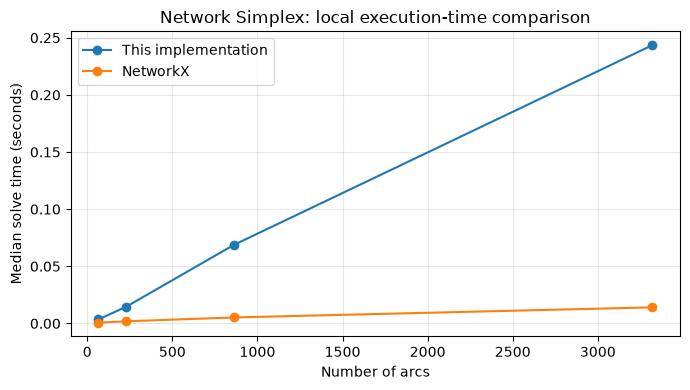

In [51]:
# (number of hubs, number of demand nodes, requested extra arcs)
SIZES = [(5, 10, 0), (10, 20, 0), (20, 40, 0), (40, 80, 0)]
REPEATS = 3
benchmark_results = []

for index, (n_hubs, n_demands, extra_arcs) in enumerate(SIZES):
    nodes, arcs = build_random_instance(n_hubs, n_demands, extra_arcs, seed=2026 + index)
    network = Network(nodes, arcs)
    graph = as_networkx_graph(nodes, arcs)

    ours_seconds, ours_result = time_call(lambda: NetworkSimplex(network).solve(), REPEATS)
    networkx_seconds, networkx_result = time_call(lambda: nx.network_simplex(graph), REPEATS)
    networkx_cost, _ = networkx_result

    assert isclose(ours_result.objective_value, networkx_cost, abs_tol=1e-9)
    benchmark_results.append({
        "nodes": len(nodes),
        "arcs": len(arcs),
        "ours_seconds": ours_seconds,
        "networkx_seconds": networkx_seconds,
        "iterations": ours_result.iterations,
    })

print(f"{'nodes':>7} {'arcs':>7} {'ours (s)':>12} {'networkx (s)':>14} {'iterations':>12}")
for row in benchmark_results:
    print(
        f"{row['nodes']:>7} {row['arcs']:>7} "
        f"{row['ours_seconds']:>12.6f} {row['networkx_seconds']:>14.6f} "
        f"{row['iterations']:>12}"
    )

plt.figure(figsize=(7, 4))
plt.plot([row['arcs'] for row in benchmark_results],
         [row['ours_seconds'] for row in benchmark_results],
         marker='o', label='This implementation')
plt.plot([row['arcs'] for row in benchmark_results],
         [row['networkx_seconds'] for row in benchmark_results],
         marker='o', label='NetworkX')
plt.xlabel('Number of arcs')
plt.ylabel('Median solve time (seconds)')
plt.title('Network Simplex: local execution-time comparison')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()